In [49]:
# Author: Chu Zhang

In [50]:
# IMPORT SECTION
# We have to start an import section in order to make it easier to MAINTAIN
import datetime #for tha dates and time
import pandas as pd #for DATA FREAMES aka the n.n data
import matplotlib.pyplot as plt #for the plots
import pandas_datareader.data as web #in industry we use GCP (Ggle Cloud Plt)
import numpy as np #for linear algebra

In [51]:
stock_ticker = "GFTC" # String : to represents labels or names
market_price = 150.25 # FLOAT
share_traded = 1000 # INTEGER
is_volatile = True # BOOLEAN

print(f"Asset: {stock_ticker}")
print(f"Market Price: {market_price}")
print(f"Number of Shares: {share_traded}")
print(f"Is Volatile: {is_volatile}")
print(f" Asset  {stock_ticker} | Price : {share_traded} | Type: {is_volatile} ")

Asset: GFTC
Market Price: 150.25
Number of Shares: 1000
Is Volatile: True
 Asset  GFTC | Price : 1000 | Type: True 


In [52]:
data = { 'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10'], 'Sector': ['Tech', 'Fin', 'Tech', 'Energy', 'Fin', 'Tech', 'Energy', 'Tech', 'Retail', 'Retail'], 'Returns': [0.05, 0.02, -0.01, 0.08, np.nan, 0.04, 0.15, -0.02, 0.01, 5.0], 'Volatility': [0.12, 0.08, 0.15, 0.20, 0.10, 0.11, 0.25, 0.13, 0.09, 0.10], 'Description': ['High growth tech', 'Stable financial', 'Volatile software', 'Oil production', 'Unknown bank', 'AI startup', 'Solar energy', 'E-commerce', 'Store A', 'Store B'] }

In [53]:
df_fin = pd.DataFrame(data)
display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description
0,A1,Tech,0.05,0.12,High growth tech
1,A2,Fin,0.02,0.08,Stable financial
2,A3,Tech,-0.01,0.15,Volatile software
3,A4,Energy,0.08,0.20,Oil production
4,A5,Fin,NaN,0.10,Unknown bank


In [54]:
# MISSING VALUES
# What do you do when you missing values ?
# The risk of missing values is to have BIAS RESULTS
# MAR / MCAR / MNAR
# MCAR: Missing Competely at RANDOM
# MAR : Missing related to obs variables
# MNAR: Missing related to the value itself


In [55]:
df_fin['Returns_Imp']= df_fin['Returns'].fillna(df_fin['Returns'].mean())
display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp
0,A1,Tech,0.05,0.12,High growth tech,0.050000
1,A2,Fin,0.02,0.08,Stable financial,0.020000
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000
3,A4,Energy,0.08,0.20,Oil production,0.080000
4,A5,Fin,NaN,0.10,Unknown bank,0.591111


In [56]:
print(f"Gaps filed with the means is not perefect but good. Total NaNs now : {df_fin['Returns_Imp'].isna().sum()}")

Gaps filed with the means is not perefect but good. Total NaNs now : 0


In [69]:
# 4. Outliers & Winsorisation
# In finance we tend to often see "FAT TAILS". Single error can RUIN A MODEL.
# WINSORISATION CAPS extreme values at specific precentiles rather than deleting them.
from scipy.stats.mstats import winsorize
df_fin['Returns_Clean']=winsorize(df_fin['Returns'], limits=[0.05,0.95])
display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp,Returns_Clean,Risk_Group,Target,Prediction
0,A1,Tech,0.05,0.12,High growth tech,0.050000,-0.02,2,1,1
1,A2,Fin,0.02,0.08,Stable financial,0.020000,-0.02,0,0,0
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000,-0.02,2,1,1
3,A4,Energy,0.08,0.20,Oil production,0.080000,-0.02,1,0,0
4,A5,Fin,NaN,0.10,Unknown bank,0.591111,-0.02,0,0,0


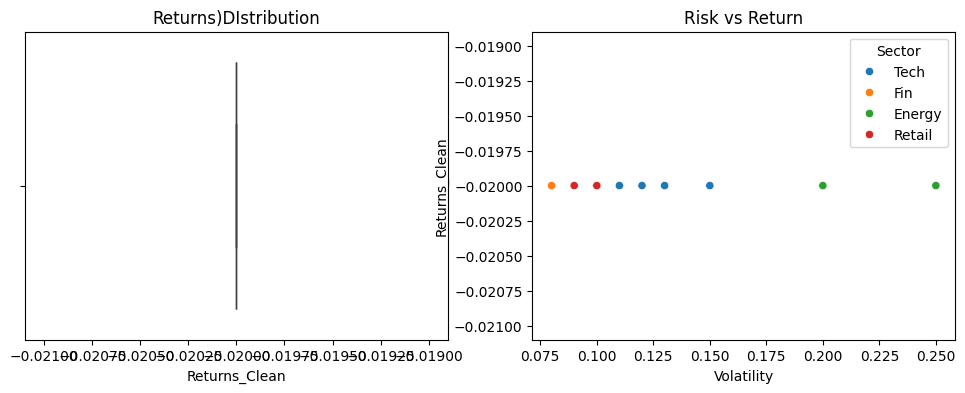

In [61]:
# DATA VIZ (visualization)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)

# We forgot to import sns thus
import seaborn as sns
sns.boxplot(x=df_fin['Returns_Clean']).set_title("Returns)DIstribution")

plt.subplot(1,2,2)
sns.scatterplot(data = df_fin, x='Volatility', y='Returns_Clean', hue='Sector').set_title("Risk vs Return")
plt.show()


In [ ]:
# 5. The cool Econometrics part
# what is the PACKAGE used for the STATISTICAL MOODEL?

In [63]:
import statsmodels.api as sm

In [65]:
X= sm.add_constant(df_fin['Volatility'])
y= df_fin['Returns_Clean']
model = sm.OLS(y,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Returns_Clean   R-squared:                     -12.900
Model:                            OLS   Adj. R-squared:                -14.638
Method:                 Least Squares   F-statistic:                    -7.424
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               1.00
Time:                        13:12:13   Log-Likelihood:                 374.68
No. Observations:                  10   AIC:                            -745.4
Df Residuals:                       8   BIC:                            -744.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0200   1.28e-17  -1.57e+15      0.0

In [66]:
# Import A SUB PART OF SKLEARN
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(df_fin[['Returns_Clean', 'Volatility']])
df_fin['Risk_Group'] = kmeans.labels_
print("Assets assignment to risk clusters.")

Assets assignment to risk clusters.


In [68]:
# But we need more! We need to PREDUCT
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report #to ease the human reading

df_fin['Target'] = (df_fin['Sector'] == 'Tech').astype(int)
X_clf = df_fin[['Returns_Clean', 'Volatility']]
y_clf = df_fin['Target']

clf = DecisionTreeClassifier().fit(X_clf, y_clf)
df_fin['Prediction'] = clf.predict(X_clf)

print(classification_report(y_clf, df_fin['Prediction']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [ ]:
# FINANCIAL DATA ANALYSIS with the Internet
# To retrive

In [70]:
import datetime
import yfinance as yf # YAHOO finance gives free API CALLS to the values of the stock markets

start_date = datetime.datetime(2020,1,1)
end_date = datetime.datetime(2023,1,1)

# Get S&P500
sp500_data = yf.download('^GSPC', start=start_date, end=end_date)
print("S&P 500 data retrived:")
display(sp500_data.head())

/tmp/ipykernel_1673/2064817418.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download('^GSPC', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

S&P 500 data retrived:


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000


1. Using SQLite (In-Money)

We can use the built-in sqlite3 to create a temporary database from our existing DataFrame.





In [73]:
# Since it is more than just simple Data Analytics
# we will need to INSTALL the SQL package
!pip install pandasql
# To install it you need the excelamation point and the pip

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=b24c2ee12bca2850e7e1b0a3a258d2668bea5c1c42c1a1d2aef29bd1b425ec59
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [74]:
import sqlite3
conn = sqlite3.connect(':memory:')
# this creates an in-money SQLite DB(database) so you use the vm of google

In [75]:
df_fin.to_sql('finance_table', conn, index=False, if_exists='replace')
#Then write the existing df_fin to the SQL database

10

In [76]:
# What are the 3 words used in SQL? (Select From Where)
# We must esure
query="SElECT Sector, AVG(Volatility) as Avg_Vol FROM finance_table GROUP BY Sector"
sql_results = pd.read_sql_query(query, conn)
print(sql_results)

   Sector  Avg_Vol
0  Energy   0.2250
1     Fin   0.0900
2  Retail   0.0950
3    Tech   0.1275


In [79]:
# What if I want ONLY SQL and no more pandas?
# I can use a LAMBDA FUCTION
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

In [83]:
query_ps= """
SELECT Asset_ID, Sector, Returns_Clean
FROM df_fin
WHERE Sector = 'Tech'
"""

sql_results_ps = pysqldf(query_ps)
print(sql_results_ps)

  Asset_ID Sector  Returns_Clean
0       A1   Tech          -0.02
1       A3   Tech          -0.02
2       A6   Tech          -0.02
3       A8   Tech          -0.02


In [85]:
asset_metadata = pd.DataFrame({ 'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5'], 'Full_Name': ['Apple Inc', 'JP Morgan', 'Microsoft', 'Exxon Mobil', 'Goldman Sachs'], 'Country': ['USA', 'USA', 'USA', 'USA', 'USA'] })

In [86]:
# The advantage of sql is the Power of joining tables
# The most used one is INNER JOIN

# We will do a API CAll for the fred
fred_df_sql = sql = fred_data.reset_index()
query_fred= """
SELECT DATE, GDP
FROM fred_df_sql
WHERE GDP > 20000
ORDER BY DATE DESC
"""
gdp_high_results = pysqldf(query_fred)
print("--- HIGH_GDP_results)


NameError: name 'fred_data' is not defined